In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import optuna
import warnings
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

print("라이브러리 로드 완료!")

라이브러리 로드 완료!


In [11]:
df_office  = pd.read_csv(r"C:\SKN23-FINAL-1TEAM\ml_research\xgbboost\officetel_processed_items_data_2026-04-22 (2).csv")
df_oneroom = pd.read_csv(r"C:\SKN23-FINAL-1TEAM\ml_research\xgbboost\oneroom_processed_items_data_2026-04-22 (1).csv")

df_office['is_officetel']  = 1
df_oneroom['is_officetel'] = 0

df = pd.concat([df_office, df_oneroom], axis=0, ignore_index=True)
print(f"합치기 후: {df.shape}")

# 결측치 처리
df = df.dropna(subset=['converted_monthly_rent'])
df.fillna(df.median(numeric_only=True), inplace=True)

# 이상치 제거
Q1 = df['converted_monthly_rent'].quantile(0.01)
Q3 = df['converted_monthly_rent'].quantile(0.99)
df = df[(df['converted_monthly_rent'] >= Q1) & (df['converted_monthly_rent'] <= Q3)]
df = df[(df['area_m2'] > 0) & (df['area_m2'] < 200)]
df = df[(df['building_age'] >= 0) & (df['building_age'] < 100)]

print(f"이상치 제거 후: {df.shape}")

합치기 후: (46324, 87)
이상치 제거 후: (45339, 87)


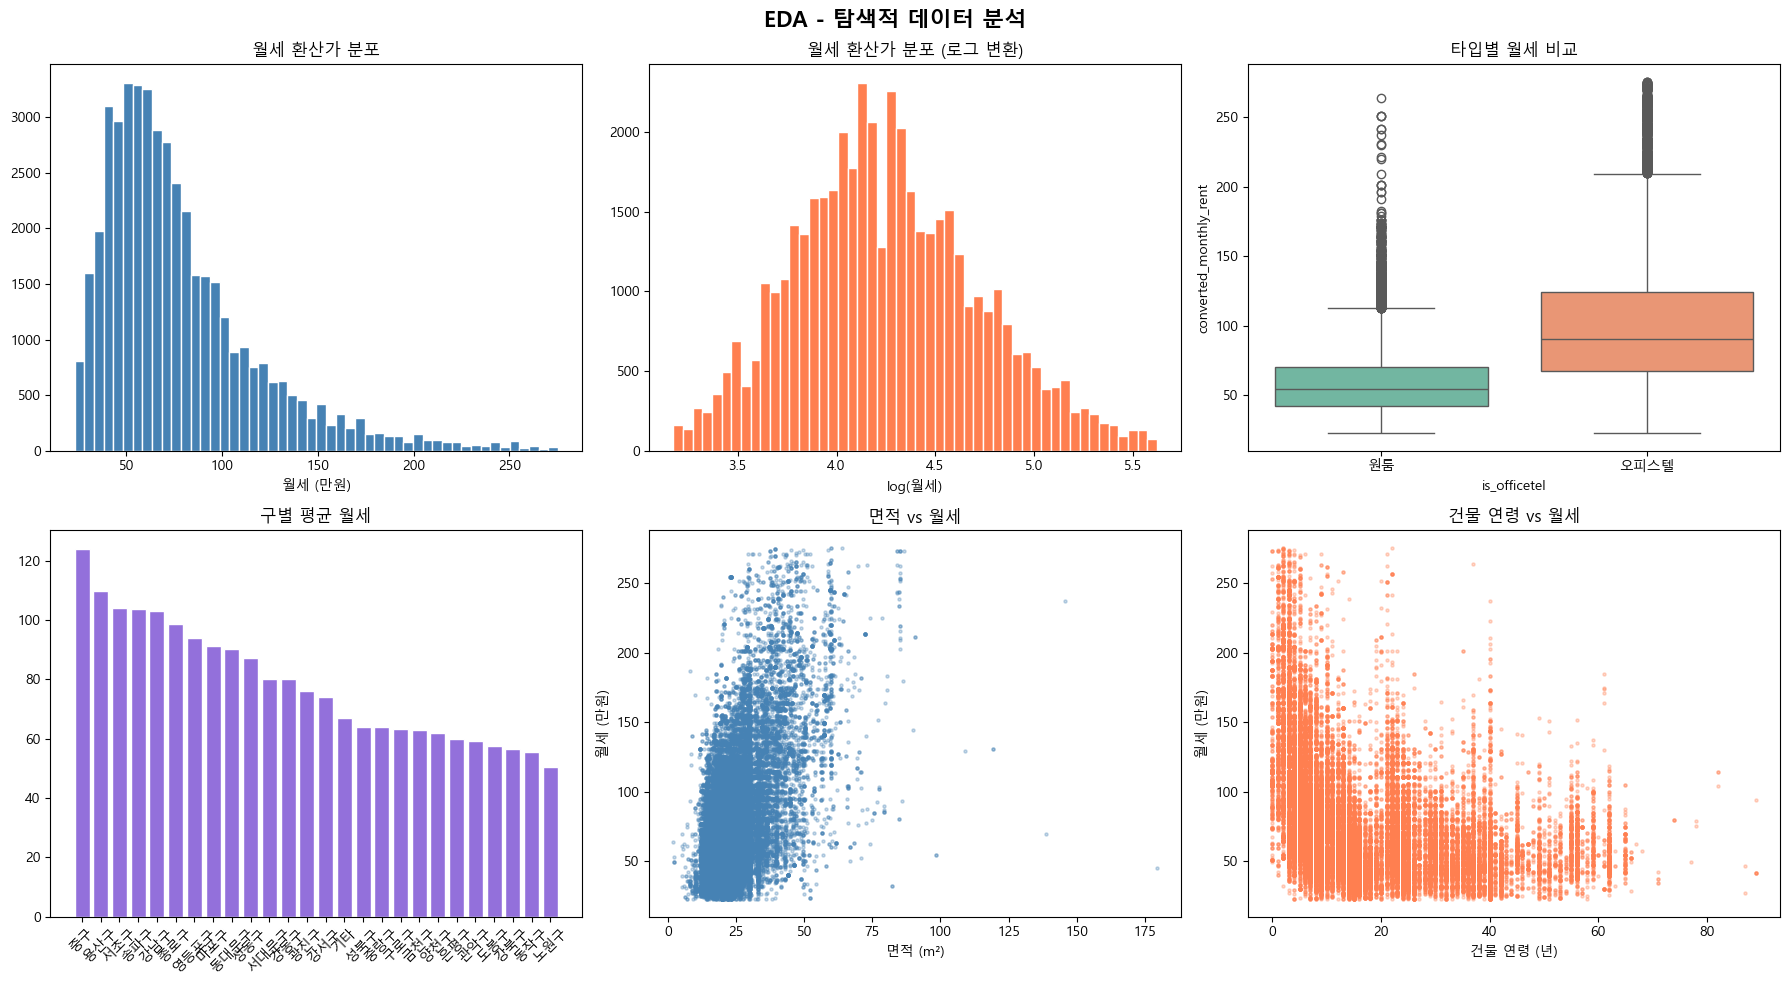

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EDA - 탐색적 데이터 분석', fontsize=16, fontweight='bold')

# 1) 월세 분포
axes[0,0].hist(df['converted_monthly_rent'], bins=50, color='steelblue', edgecolor='white')
axes[0,0].set_title('월세 환산가 분포')
axes[0,0].set_xlabel('월세 (만원)')

# 2) 로그 변환 후 분포
axes[0,1].hist(np.log1p(df['converted_monthly_rent']), bins=50, color='coral', edgecolor='white')
axes[0,1].set_title('월세 환산가 분포 (로그 변환)')
axes[0,1].set_xlabel('log(월세)')

# 3) 원룸 vs 오피스텔 박스플롯
sns.boxplot(x='is_officetel', y='converted_monthly_rent', data=df, ax=axes[0,2], palette='Set2')
axes[0,2].set_xticks([0, 1])
axes[0,2].set_xticklabels(['원룸', '오피스텔'])
axes[0,2].set_title('타입별 월세 비교')

# 4) 구별 평균 월세
district_cols = [c for c in df.columns if c.startswith('district_')]
district_mean = {col.replace('district_', ''): df[df[col]==1]['converted_monthly_rent'].mean()
                 for col in district_cols}
district_df = pd.Series(district_mean).sort_values(ascending=False)
axes[1,0].bar(district_df.index, district_df.values, color='mediumpurple', edgecolor='white')
axes[1,0].set_title('구별 평균 월세')
axes[1,0].tick_params(axis='x', rotation=45)

# 5) 면적 vs 월세
axes[1,1].scatter(df['area_m2'], df['converted_monthly_rent'], alpha=0.3, s=5, color='steelblue')
axes[1,1].set_title('면적 vs 월세')
axes[1,1].set_xlabel('면적 (m²)')
axes[1,1].set_ylabel('월세 (만원)')

# 6) 건물 연령 vs 월세
axes[1,2].scatter(df['building_age'], df['converted_monthly_rent'], alpha=0.3, s=5, color='coral')
axes[1,2].set_title('건물 연령 vs 월세')
axes[1,2].set_xlabel('건물 연령 (년)')
axes[1,2].set_ylabel('월세 (만원)')

plt.tight_layout()
plt.show()

In [13]:
# 원룸 / 오피스텔 분리
drop_cols = ['converted_monthly_rent', 'movein_date', 'is_officetel']

# 원룸
df_one = df[df['is_officetel'] == 0].copy()
X_oneroom = df_one.drop(columns=[c for c in drop_cols if c in df_one.columns])
y_oneroom = np.log1p(df_one['converted_monthly_rent'])

X_train_one, X_test_one, y_train_one, y_test_one = train_test_split(
    X_oneroom, y_oneroom, test_size=0.2, random_state=42
)

# 오피스텔
df_off = df[df['is_officetel'] == 1].copy()
X_officetel = df_off.drop(columns=[c for c in drop_cols if c in df_off.columns])
y_officetel = np.log1p(df_off['converted_monthly_rent'])

X_train_off, X_test_off, y_train_off, y_test_off = train_test_split(
    X_officetel, y_officetel, test_size=0.2, random_state=42
)

print(f"원룸    학습: {X_train_one.shape} | 검증: {X_test_one.shape}")
print(f"오피스텔 학습: {X_train_off.shape} | 검증: {X_test_off.shape}")

원룸    학습: (20025, 84) | 검증: (5007, 84)
오피스텔 학습: (16245, 84) | 검증: (4062, 84)


In [14]:
# 원룸 Optuna
def objective_one(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 200, 800),
        'max_depth'        : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'gamma'            : trial.suggest_float('gamma', 0.0, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 0.5, 2.0),
        'random_state'     : 42,
        'device'           : 'cpu',
    }
    model = XGBRegressor(**params)
    score = cross_val_score(model, X_train_one, y_train_one,
                            cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
    return score.mean()

print("원룸 Optuna 튜닝 시작 (50 trials)...")
study_one = optuna.create_study(direction='maximize')
study_one.optimize(objective_one, n_trials=50, show_progress_bar=True)
print(f"원룸 최적 CV RMSE: {-study_one.best_value:.4f}")

# 오피스텔 Optuna
def objective_off(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 200, 800),
        'max_depth'        : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'gamma'            : trial.suggest_float('gamma', 0.0, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 0.5, 2.0),
        'random_state'     : 42,
        'device'           : 'cpu',
    }
    model = XGBRegressor(**params)
    score = cross_val_score(model, X_train_off, y_train_off,
                            cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
    return score.mean()

print("\n오피스텔 Optuna 튜닝 시작 (50 trials)...")
study_off = optuna.create_study(direction='maximize')
study_off.optimize(objective_off, n_trials=50, show_progress_bar=True)
print(f"오피스텔 최적 CV RMSE: {-study_off.best_value:.4f}")

원룸 Optuna 튜닝 시작 (50 trials)...


Best trial: 16. Best value: -0.126371: 100%|██████████| 50/50 [03:44<00:00,  4.48s/it]


원룸 최적 CV RMSE: 0.1264

오피스텔 Optuna 튜닝 시작 (50 trials)...


Best trial: 27. Best value: -0.0919201: 100%|██████████| 50/50 [02:47<00:00,  3.35s/it]

오피스텔 최적 CV RMSE: 0.0919


In [15]:
# 원룸 모델
best_params_one = study_one.best_params
best_params_one.update({'random_state': 42, 'device': 'cpu',
                        'eval_metric': 'rmse', 'early_stopping_rounds': 30})

model_oneroom = XGBRegressor(**best_params_one)
model_oneroom.fit(
    X_train_one, y_train_one,
    eval_set=[(X_train_one, y_train_one), (X_test_one, y_test_one)],
    verbose=50
)

y_pred_one = np.expm1(model_oneroom.predict(X_test_one))
y_true_one = np.expm1(y_test_one)

rmse_one = np.sqrt(mean_squared_error(y_true_one, y_pred_one))
mae_one  = mean_absolute_error(y_true_one, y_pred_one)
r2_one   = r2_score(y_true_one, y_pred_one)

print(f"\n{'='*35}")
print(f"  [원룸 모델]")
print(f"  RMSE : {rmse_one:>10,.2f} 만원")
print(f"  MAE  : {mae_one:>10,.2f} 만원")
print(f"  R²   : {r2_one:>10.4f}")
print(f"{'='*35}")

# 오피스텔 모델
best_params_off = study_off.best_params
best_params_off.update({'random_state': 42, 'device': 'cpu',
                        'eval_metric': 'rmse', 'early_stopping_rounds': 30})

model_officetel = XGBRegressor(**best_params_off)
model_officetel.fit(
    X_train_off, y_train_off,
    eval_set=[(X_train_off, y_train_off), (X_test_off, y_test_off)],
    verbose=50
)

y_pred_off = np.expm1(model_officetel.predict(X_test_off))
y_true_off = np.expm1(y_test_off)

rmse_off = np.sqrt(mean_squared_error(y_true_off, y_pred_off))
mae_off  = mean_absolute_error(y_true_off, y_pred_off)
r2_off   = r2_score(y_true_off, y_pred_off)

print(f"\n{'='*35}")
print(f"  [오피스텔 모델]")
print(f"  RMSE : {rmse_off:>10,.2f} 만원")
print(f"  MAE  : {mae_off:>10,.2f} 만원")
print(f"  R²   : {r2_off:>10.4f}")
print(f"{'='*35}")

[0]	validation_0-rmse:0.34556	validation_1-rmse:0.34469
[50]	validation_0-rmse:0.14384	validation_1-rmse:0.15897
[100]	validation_0-rmse:0.11950	validation_1-rmse:0.14340
[150]	validation_0-rmse:0.09982	validation_1-rmse:0.13297
[200]	validation_0-rmse:0.08527	validation_1-rmse:0.12633
[250]	validation_0-rmse:0.07455	validation_1-rmse:0.12162
[300]	validation_0-rmse:0.06547	validation_1-rmse:0.11838
[350]	validation_0-rmse:0.05732	validation_1-rmse:0.11542
[400]	validation_0-rmse:0.05106	validation_1-rmse:0.11350
[450]	validation_0-rmse:0.04567	validation_1-rmse:0.11195
[500]	validation_0-rmse:0.04107	validation_1-rmse:0.11075
[506]	validation_0-rmse:0.04052	validation_1-rmse:0.11065

  [원룸 모델]
  RMSE :       7.08 만원
  MAE  :       4.34 만원
  R²   :     0.9065
[0]	validation_0-rmse:0.39233	validation_1-rmse:0.38843
[50]	validation_0-rmse:0.07458	validation_1-rmse:0.10315
[100]	validation_0-rmse:0.05862	validation_1-rmse:0.09396
[150]	validation_0-rmse:0.04800	validation_1-rmse:0.08942
[

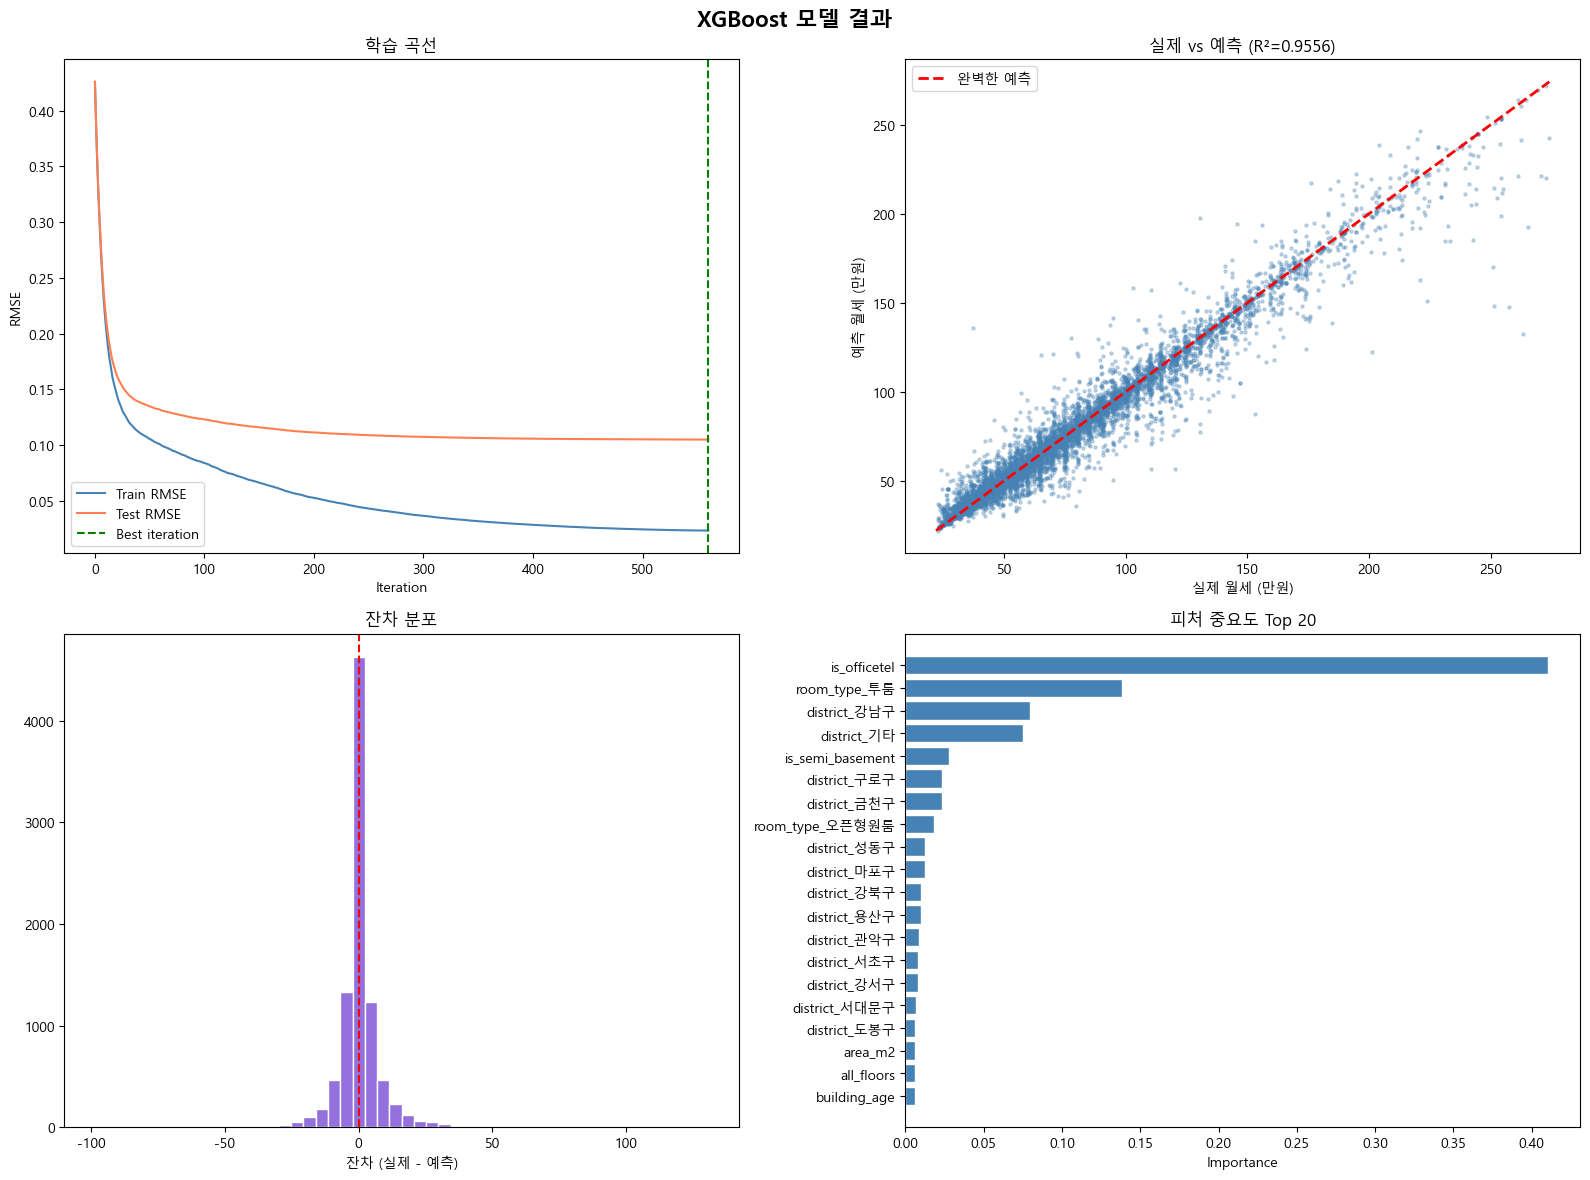

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('XGBoost 모델 결과', fontsize=16, fontweight='bold')

# 1) 학습 곡선
results = final_model.evals_result()
axes[0,0].plot(results['validation_0']['rmse'], label='Train RMSE', color='steelblue')
axes[0,0].plot(results['validation_1']['rmse'], label='Test RMSE', color='coral')
axes[0,0].axvline(x=final_model.best_iteration, color='green', linestyle='--', label='Best iteration')
axes[0,0].set_title('학습 곡선')
axes[0,0].set_xlabel('Iteration')
axes[0,0].set_ylabel('RMSE')
axes[0,0].legend()

# 2) 실제 vs 예측 산점도
axes[0,1].scatter(y_true, y_pred, alpha=0.3, s=5, color='steelblue')
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
axes[0,1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='완벽한 예측')
axes[0,1].set_title(f'실제 vs 예측 (R²={r2:.4f})')
axes[0,1].set_xlabel('실제 월세 (만원)')
axes[0,1].set_ylabel('예측 월세 (만원)')
axes[0,1].legend()

# 3) 잔차 분포
residuals = y_true - y_pred          
axes[1,0].hist(residuals, bins=50, color='mediumpurple', edgecolor='white')
axes[1,0].axvline(x=0, color='red', linestyle='--')
axes[1,0].set_title('잔차 분포')
axes[1,0].set_xlabel('잔차 (실제 - 예측)')

# 4) 피처 중요도 Top 20
importance = pd.Series(final_model.feature_importances_, index=X.columns)
top20 = importance.nlargest(20).sort_values()
axes[1,1].barh(top20.index, top20.values, color='steelblue', edgecolor='white')
axes[1,1].set_title('피처 중요도 Top 20')
axes[1,1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

In [17]:
model_oneroom.save_model(r"C:\SKN23-FINAL-1TEAM\ml_research\xgbboost\xgb_oneroom.json")
model_officetel.save_model(r"C:\SKN23-FINAL-1TEAM\ml_research\xgbboost\xgb_officetel.json")
print("원룸 모델 저장 완료!")
print("오피스텔 모델 저장 완료!")

원룸 모델 저장 완료!
오피스텔 모델 저장 완료!


In [18]:
# 데이터 리키지 확인용 - 이거 한번 돌려보세요
print(df.corr()['converted_monthly_rent'].sort_values(ascending=False).head(10))

converted_monthly_rent    1.000000
area_m2                   0.560914
room_type_투룸              0.514194
is_officetel              0.511749
all_floors                0.485944
manage_cost               0.459631
floor                     0.424625
has_parking               0.384848
has_elevator              0.372540
room_quality_score        0.300930
Name: converted_monthly_rent, dtype: float64



  [원룸] 과적합 체크

[1] Train vs Test 성능 비교
  Train RMSE :     2.79 만원  |  Test RMSE :     7.08 만원
  Train R²   :   0.9854      |  Test R²   :   0.9065

  RMSE 차이 (Test - Train) : +4.29 만원
  R²   차이 (Train - Test) : +0.0789

  ⚠️  과적합 의심! 차이가 큽니다.

[2] 학습 곡선 계산 중... (시간이 조금 걸릴 수 있어요)

[3] 5-Fold Cross Validation
  CV RMSE 평균 : 0.1264
  CV RMSE 표준편차 : 0.0035
  ✅  CV 편차 안정적


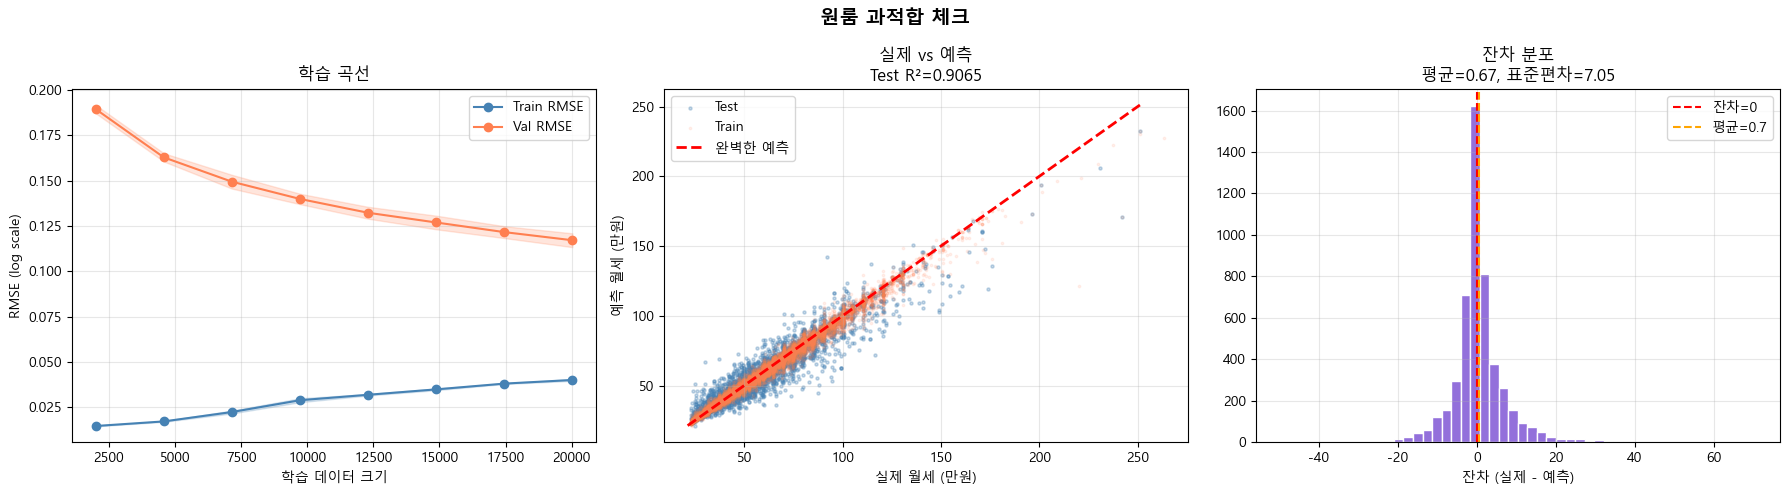


  📊 그래프 저장 완료: 원룸_overfitting_check.png

  [오피스텔] 과적합 체크

[1] Train vs Test 성능 비교
  Train RMSE :     3.61 만원  |  Test RMSE :     9.55 만원
  Train R²   :   0.9937      |  Test R²   :   0.9557

  RMSE 차이 (Test - Train) : +5.94 만원
  R²   차이 (Train - Test) : +0.0380

  ⚠️  과적합 의심! 차이가 큽니다.

[2] 학습 곡선 계산 중... (시간이 조금 걸릴 수 있어요)

[3] 5-Fold Cross Validation
  CV RMSE 평균 : 0.0919
  CV RMSE 표준편차 : 0.0019
  ✅  CV 편차 안정적


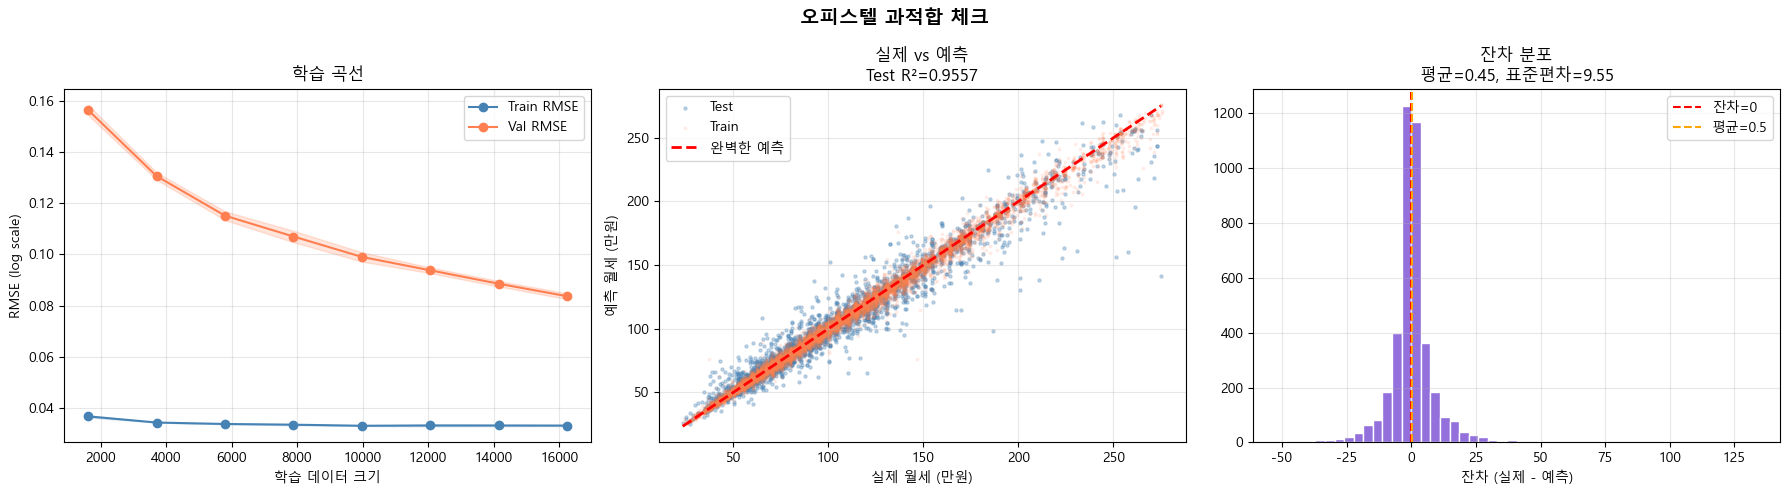


  📊 그래프 저장 완료: 오피스텔_overfitting_check.png

  최종 과적합 요약

  [원룸]
  RMSE 차이  : +4.29 만원  ✅ 양호
  CV 안정성  : 0.0035       ✅ 안정적

  [오피스텔]
  RMSE 차이  : +5.94 만원  ⚠️ 과적합 의심
  CV 안정성  : 0.0019       ✅ 안정적


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# ============================================================
# 0. 모델 & 데이터 준비 (기존 노트북 변수 그대로 사용)
# ============================================================
# 아래 변수들은 기존 노트북에서 이미 만들어진 것들입니다:
# model_oneroom, model_officetel
# X_train_one, X_test_one, y_train_one, y_test_one
# X_train_off, X_test_off, y_train_off, y_test_off

def check_overfitting(model, X_train, X_test, y_train, y_test, model_name="모델"):
    """
    과적합 종합 체크 함수
    """
    print(f"\n{'='*50}")
    print(f"  [{model_name}] 과적합 체크")
    print(f"{'='*50}")

    # ── 1. Train vs Test 성능 비교 ──────────────────────────
    y_pred_train = np.expm1(model.predict(X_train))
    y_pred_test  = np.expm1(model.predict(X_test))
    y_true_train = np.expm1(y_train)
    y_true_test  = np.expm1(y_test)

    train_rmse = np.sqrt(mean_squared_error(y_true_train, y_pred_train))
    test_rmse  = np.sqrt(mean_squared_error(y_true_test,  y_pred_test))
    train_r2   = r2_score(y_true_train, y_pred_train)
    test_r2    = r2_score(y_true_test,  y_pred_test)

    print(f"\n[1] Train vs Test 성능 비교")
    print(f"  Train RMSE : {train_rmse:>8.2f} 만원  |  Test RMSE : {test_rmse:>8.2f} 만원")
    print(f"  Train R²   : {train_r2:>8.4f}      |  Test R²   : {test_r2:>8.4f}")

    rmse_gap = test_rmse - train_rmse
    r2_gap   = train_r2 - test_r2

    print(f"\n  RMSE 차이 (Test - Train) : {rmse_gap:+.2f} 만원")
    print(f"  R²   차이 (Train - Test) : {r2_gap:+.4f}")

    if rmse_gap > 5 or r2_gap > 0.05:
        print(f"\n  ⚠️  과적합 의심! 차이가 큽니다.")
    else:
        print(f"\n  ✅  과적합 없음. 양호한 수준입니다.")

    # ── 2. 학습 곡선 (Learning Curve) ───────────────────────
    print(f"\n[2] 학습 곡선 계산 중... (시간이 조금 걸릴 수 있어요)")

    # early_stopping은 eval_set이 필요해서 learning_curve에서 제거
    params = model.get_params()
    params.pop('early_stopping_rounds', None)
    params.pop('eval_metric', None)

    train_sizes, train_scores, val_scores = learning_curve(
        XGBRegressor(**params),
        pd.concat([X_train, X_test]),
        np.concatenate([y_train, y_test]),
        cv=5,
        scoring='neg_root_mean_squared_error',
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1
    )

    train_mean = -train_scores.mean(axis=1)
    val_mean   = -val_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_std    = val_scores.std(axis=1)

    # ── 3. Cross Validation ─────────────────────────────────
    print(f"\n[3] 5-Fold Cross Validation")
    cv_scores = cross_val_score(
        XGBRegressor(**params),  # early_stopping 제거된 params 재사용
        X_train, y_train,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    cv_rmse = -cv_scores
    print(f"  CV RMSE 평균 : {cv_rmse.mean():.4f}")
    print(f"  CV RMSE 표준편차 : {cv_rmse.std():.4f}")

    if cv_rmse.std() > 0.02:
        print(f"  ⚠️  CV 편차가 큼 → 불안정한 모델일 수 있음")
    else:
        print(f"  ✅  CV 편차 안정적")

    # ── 4. 시각화 ───────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{model_name} 과적합 체크', fontsize=14, fontweight='bold')

    # (a) 학습 곡선
    axes[0].plot(train_sizes, train_mean, 'o-', color='steelblue', label='Train RMSE')
    axes[0].plot(train_sizes, val_mean,   'o-', color='coral',     label='Val RMSE')
    axes[0].fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='steelblue')
    axes[0].fill_between(train_sizes, val_mean   - val_std,   val_mean   + val_std,   alpha=0.2, color='coral')
    axes[0].set_title('학습 곡선')
    axes[0].set_xlabel('학습 데이터 크기')
    axes[0].set_ylabel('RMSE (log scale)')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # (b) 실제 vs 예측
    axes[1].scatter(y_true_test, y_pred_test, alpha=0.3, s=5, color='steelblue', label='Test')
    axes[1].scatter(y_true_train, y_pred_train, alpha=0.1, s=3, color='coral', label='Train')
    min_val = min(y_true_test.min(), y_pred_test.min())
    max_val = max(y_true_test.max(), y_pred_test.max())
    axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='완벽한 예측')
    axes[1].set_title(f'실제 vs 예측\nTest R²={test_r2:.4f}')
    axes[1].set_xlabel('실제 월세 (만원)')
    axes[1].set_ylabel('예측 월세 (만원)')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # (c) 잔차 분포
    residuals = y_true_test - y_pred_test
    axes[2].hist(residuals, bins=50, color='mediumpurple', edgecolor='white')
    axes[2].axvline(x=0, color='red', linestyle='--', label='잔차=0')
    axes[2].axvline(x=residuals.mean(), color='orange', linestyle='--', label=f'평균={residuals.mean():.1f}')
    axes[2].set_title(f'잔차 분포\n평균={residuals.mean():.2f}, 표준편차={residuals.std():.2f}')
    axes[2].set_xlabel('잔차 (실제 - 예측)')
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{model_name}_overfitting_check.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n  📊 그래프 저장 완료: {model_name}_overfitting_check.png")

    return {
        "train_rmse": train_rmse,
        "test_rmse":  test_rmse,
        "train_r2":   train_r2,
        "test_r2":    test_r2,
        "rmse_gap":   rmse_gap,
        "cv_mean":    cv_rmse.mean(),
        "cv_std":     cv_rmse.std(),
    }


# ============================================================
# 실행
# ============================================================
result_one = check_overfitting(
    model_oneroom,
    X_train_one, X_test_one,
    y_train_one, y_test_one,
    model_name="원룸"
)

result_off = check_overfitting(
    model_officetel,
    X_train_off, X_test_off,
    y_train_off, y_test_off,
    model_name="오피스텔"
)

# ============================================================
# 최종 요약
# ============================================================
print(f"\n{'='*50}")
print(f"  최종 과적합 요약")
print(f"{'='*50}")
for name, r in [("원룸", result_one), ("오피스텔", result_off)]:
    print(f"\n  [{name}]")
    print(f"  RMSE 차이  : {r['rmse_gap']:+.2f} 만원  {'⚠️ 과적합 의심' if r['rmse_gap'] > 5 else '✅ 양호'}")
    print(f"  CV 안정성  : {r['cv_std']:.4f}       {'⚠️ 불안정' if r['cv_std'] > 0.02 else '✅ 안정적'}")